In [1]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install("spacy")

In [2]:
from composer import *
from bs4 import BeautifulSoup
import requests
import re
import networkx as nx
import spacy
import numpy as np
import math
import time
import pickle
import json
from ipysigma import Sigma

## NLP pour identifier des influences directes via les notices biographiques

In [3]:
"""cette cellule permet de retrouver tous les noms de compositeurs cités dans l'article wikipedia du compositeur d'intérêt et d'en dresser la liste dans un dictionnaire dont les clés sont les id des compositeurs en question"""

def get_person_entities(text):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    L=[]
    for ent in doc.ents:
        if ent.label_=='PERSON':
            #print(ent.text, ent.start_char, ent.end_char, ent.label_)
            L.append(ent.text)
    #print(L)
    return L
    
            
def get_wikipedia_page_metadata(name):
    language_code = 'en'
    search_query = name
    number_of_results = 1
    """headers = {
      # 'Authorization': 'Bearer ACCESS_TOKEN',
      'User-Agent': 'APP_NAME (EMAIL_OR_CONTACT_PAGE)'
    }"""
    base_url = 'https://api.wikimedia.org/core/v1/wikipedia/'
    endpoint = '/search/page'
    url = base_url + language_code + endpoint
    parameters = {'q': search_query, 'limit': number_of_results}
    response = requests.get(url, params=parameters)
    dico_response = json.loads(response.text)
    for page in dico_response['pages']:
      display_title = page['title']
      article_url = 'https://' + language_code + '.wikipedia.org/wiki/' + page['key']
      try:
        article_description = page['description']
      except:
        article_description = 'a Wikipedia article'
      try:
        thumbnail_url = 'https:' + page['thumbnail']['url']
      except:
        thumbnail_url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/8/80/Wikipedia-logo-v2.svg/200px-Wikipedia-logo-v2.svg.png'
        

def get_wikipedia_page_text_with_api(title):
    endpoint = "https://en.wikipedia.org/w/api.php"
    params = {
        'action': 'parse',
        'page': title,
        'format': 'json',
        'prop': 'text',
    }

    response = requests.get(endpoint, params=params)
    data = response.json()

    if 'parse' in data:
        html_content = data['parse']['text']['*']
        soup = BeautifulSoup(html_content, 'html.parser')
        text = soup.get_text()
        return text
    else:
        return "Page not found or error occurred"
    
def get_wikipedia_page_text(name,language="en"):
    url = f"https://{language}.wikipedia.org/w/index.php?search={name}"
    page = requests.get(url)
    soup = BeautifulSoup(page.content, "html.parser")
    text=soup.get_text()
    if language =="en" and (name+" - Wikipedia" in text or name.split(" ")[-1]+" - Wikipedia" in text):
        return get_wikipedia_page_text(name+" (composer)")
    elif language=="fr" and (name+" - Wikipédia" in text or name.split(" ")[-1]+" - Wikipédia" in text):
        return get_wikipedia_page_text(name+" (compositeur)")
    return text


## filtre pour ne conserver que les noms de compositeurs

In [4]:
def composer_filter_by_dict(list_of_names, dico):
    """filtre les noms qui sont ceux de compositeurs à partir d'un dictionnaire de compositeurs, évite d'avoir à rechercher dans wikidata à chaque fois donc plus rapide mais moins robuste, à compléter peut-être avec le TD qui utilisait des Trie"""
    list_of_names = list(filter(lambda x: x.strip() in dico, list_of_names))
    return list_of_names

#composer_filter_by_dict(["Richard Wagner","Bach","Mozart"],{"Richard Wagner":(1813,1883),"Johann Sebastian Bach":(1685,1750)})
        
def composer_filter_old(list_of_names):
    compo_dico={}
    for n in list_of_names:
        c_id = find_id(n)
        if c_id is not None and c_id not in compo_dico:
            c = is_composer(c_id,n)
            #print(is_composer(n))
            if c is not None :
                compo_dico[c_id]=c
                print(n,"is a composer")
    return compo_dico

def composer_filter(list_of_names):
    compo_dico={}
    cpt=0
    for n in list_of_names:
        c_id = find_id(n)
        if c_id is not None and c_id not in compo_dico:
            c = is_composer(c_id,n)
            #print(is_composer(n))
            if c is not None :
                if cpt==0:
                    compo=c
                compo_dico[c_id]=c
                print(n,f"is the composer number {cpt} found in {compo}'s page")
                cpt+=1
    return compo,compo_dico

#compo_dico=composer_filter(["Bach","Beethoven","Wagner"])
#print(compo_dico)


In [5]:
def find_compositional_influences(name,fr=False):#problème : l'algo saute souvent Beethoven, y compris chez Wagner
    content = get_wikipedia_page_text(name)
    if fr:
        content+=get_wikipedia_page_text(name,"fr")
    persons = get_person_entities(content)
    return(composer_filter(persons))

def build_list_of_influences(enum_of_composers,french=False):
    list_of_influ_dict=[]
    for composer in enum_of_composers:
        list_of_influ_dict.append(find_compositional_influences(composer,fr=french))
    return list_of_influ_dict

#compos = ["André-Ernest-Modeste Grétry","Ernest Chausson","Gabriel Dupont","Paul le Flem"]
#compos = ["Franz Lachner","Jean Cras"]
#compos = ["Henri Duparc"]

#list_of_dico=build_list_of_influences(compos,True)
#print(list_of_dico)

In [6]:
"""essayons de qualifier les relations d'influence entre compositeurs plus précisément qu'avec la seule présence de l'un dans la page wikipedia de l'autre"""
"""compléter avec les influences - même peu nombreuses - spécifiées dans wikidata"""
"""penser à prévoir le cas d'un compositeur encore vivant"""
"""ajouter une détection des liens vers des pages de compositeurs sur wikipedia"""
def orienting_with_dates_sparql(list_of_dico,influences={}):
    """returning an adjacency list from the dict of composers appearing in the wiki notice of the first one in the dict; orienting the influence relations when no doubt exists because of birth-death dates"""
    sparql_endpoint = "https://query.wikidata.org/sparql"
    for dico in list_of_dico:
        cpt=0
        for c in dico:
            #if c.birth is None or c.death is None:#à améliorer
            time.sleep(1)  # 0.5s between requests
            query = f"""
                    SELECT ?birth ?death WHERE {{
                        wd:{c} wdt:P569 ?birth.
                        wd:{c} wdt:P570 ?death.
                    }}
                    """
                
            if cpt>0:#the rest of the dict are the composers who may have or have been influenced our musician of interest "compo"
                response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                print("Status Code:", response.status_code)
                #print("Response Text:", response.text)
                dates_dict = response.json()
                bindings = dates_dict.get("results", {}).get("bindings", [])
                if bindings:
                    birth_date = int(bindings[0].get("birth", {}).get("value").split("-")[0])                                                             #, "Unknown")
                    #c.birth=birth_date
                    death_date = int(bindings[0].get("death", {}).get("value").split("-")[0])
                    #c.death=death_date

                if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)
                elif birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                    influences[compo].append(c)
                else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other 
                    influences[compo].append(c)
                    if c not in influences :
                        influences[c]=[]
                    influences[c].append(compo)

            else:#the first element of the dictionary is the composer we are interested in : "compo"
                compo = c
                if compo not in influences:
                    influences[compo]=[]
                response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                dates_dict = response.json()
                bindings = dates_dict.get("results", {}).get("bindings", [])
                if bindings:
                    birth_date_compo = int(bindings[0].get("birth", {}).get("value").split("-")[0])
                                                                                 #, "Unknown")
                    #compo.birth=birth_date_compo
                    death_date_compo = int(bindings[0].get("death", {}).get("value").split("-")[0])
                    #compo.death=death_date_compo
                #else:
                #    birth_date_compo = "Unknown"
                #    death_date_compo = "Unknown"
                #print(birth_date_compo,death_date_compo)
                #if birth_date_compo != "Unknown" and death_date_compo != "Unknown"
                cpt+=1
        
    return influences

def orienting_with_dates_old(list_of_dico,influences={}):
    """returning an adjacency list from the dict of composers appearing in the wiki notice of the first one in the dict; orienting the influence relations when no doubt exists because of birth-death dates"""
    for dico in list_of_dico:
        cpt=0
        for c in dico.values():
            if cpt>0 :
                if c.birth is not None and c.death is not None :#the rest of the dict are the composers who may have or have been influenced our musician of interest "compo"
                    print("db:"+c.birth.split("-")[0].strip())
                    birth_date = int(c.birth.split("-")[0].strip())
                    print("intdb:"+str(birth_date))
                    death_date = int(c.death.split("-")[0].strip())
                    print(death_date)

                    if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                        if c not in influences :
                            influences[c]=[]
                        influences[c].append(compo)
                    elif birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                        influences[compo].append(c)
                    else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other 
                        influences[compo].append(c)
                        if c not in influences :
                            influences[c]=[]
                        influences[c].append(compo)

            else:#the first element of the dictionary is the composer we are interested in : "compo"
                compo = c
                if compo not in influences:
                    influences[compo]=[]
                #response = requests.get(sparql_endpoint, params={'query': query, 'format': 'json'})
                #dates_dict = response.json()
                #bindings = dates_dict.get("results", {}).get("bindings", [])
                #if bindings:
                if c.birth is not None and c.death is not None :
                    print("db:"+c.birth.split("-")[0].strip())
                    birth_date_compo = int(c.birth.split("-")[0].strip())
                    print("intdb:"+str(birth_date_compo)) #, "Unknown")
                    death_date_compo = int(c.death.split("-")[0].strip())#to do : prevoir un compositeur vivant...
                    print(death_date_compo)
                #else:
                #    birth_date_compo = "Unknown"
                #    death_date_compo = "Unknown"
                #print(birth_date_compo,death_date_compo)
                #if birth_date_compo != "Unknown" and death_date_compo != "Unknown"
                cpt+=1
    return influences

#print(list_of_dico)
#adj_list_sparql=orienting_with_dates_sparql(list_of_dico)
#adj_list=orienting_with_dates(list_of_dico)
#print(adj_list==adj_list_sparql)
#print(adj_list)

def orienting_with_dates(list_of_dico,compo_dico={}):
    """completing the influences of all encountered compsoers; orienting the influence relations when no doubt exists because of birth-death dates"""

    for compo,dico in list_of_dico:
        cpt=0
        b=False #boolean equal to True iff we have access the the birth date of the first composer
        d=False #boolean equal to True iff we have access the the death date of the first composer
        #print(dico)
        for c in dico.values():

            if c.id not in compo_dico :
                compo_dico[c.id]=c

            if cpt==0: #the first element of each dictionary is the one whose wikipedia page was used to retrieve all the others present in the current dictionary
                #compo = compo_dico[c.id]
                cpt+=1
                print("1st composer of this page :",compo,compo.id,compo_dico[compo.id].influences)
                birth_date_compo = compo.birth
                death_date_compo = compo.death
                if birth_date_compo is not None :
                    print("db:"+str(compo.birth))
                    b = True

                if death_date_compo is not None :
                    print("dd:"+str(compo.death))
                    d = True

            else :
                birth_date = c.birth
                death_date = c.death

                if d and birth_date is not None:
                    if birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                        compo_dico[compo.id].influences.add(c)
                        print(f"added {c} to {compo_dico[compo.id]}")
                    elif b and death_date is not None:
                        if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                            compo_dico[c.id].influences.add(compo)
                            print(f"added {compo_dico[compo.id]} to {c}")
                        else:
                            compo_dico[compo.id].influences.add(c)
                            print(f"added {c} to {compo_dico[compo.id]} in the new way")
                            compo_dico[c.id].influences.add(compo)
                            print(f"added {compo_dico[compo.id]} to {c}")
                    else:
                        compo_dico[compo.id].influences.add(c)
                        print(f"added {c} to {compo_dico[compo.id]}")
                        compo_dico[c.id].influences.add(compo)
                        print(f"added {compo_dico[compo.id]} to {c}")

                elif b and death_date is not None:
                        if death_date < birth_date_compo+20:#if the current composer c died at most 20 years after the birth of compo we assume compo could not influence c and that only c influenced compo
                            compo_dico[c.id].influences.add(compo)
                            print(f"added {compo_dico[compo.id]} to {c}")
                        #elif d and birth_date is not None:
                        #    if birth_date > death_date_compo-20:#if compo died at most 2O years after the birth of c then we assume only compo could influence c and not the other way around
                        #        compo_dico[compo.id].influences.add(c)
                        else:
                            compo_dico[compo.id].influences.add(c)
                            print(f"added {c} to {compo_dico[compo.id]}")
                            compo_dico[c.id].influences.add(compo)
                            print(f"added {compo_dico[compo.id]} to {c}")

                else:#we cannot say anything for sure since they were contemporary so by default we assume they influenced each other
                    compo_dico[compo.id].influences.add(c)
                    print(f"added {c} to {compo_dico[compo.id]}")
                    compo_dico[c.id].influences.add(compo)
                    print(f"added {compo_dico[compo.id]} to {c}")
        print(compo_dico[compo.id],"has influenced",compo_dico[compo.id].influences)

    return compo_dico





In [7]:
def build_graph_from_adj_list(adj_list,G=nx.DiGraph()):
    #in_G_set = {}
    for compo in adj_list:
        #G.add_node(compo)
        #in_G_set.add(compo)
        for c in adj_list[compo]:
            #if c not in in_G_set:
                #G.add_node(compo)
            G.add_edge(compo,c)
    return G

#G=build_graph_from_adj_list(adj_list_sparql)
#nx.draw(G, with_labels=True)#, labels = nx.get_node_attributes(graph, 'nom complet'))

In [8]:
def graph_of_influences_old(list_of_compo_names):
    list_of_influ_dicts=build_list_of_influences(list_of_compo_names,True)#put false if you're only interested in the english wiki
    adj_list = orienting_with_dates_old(list_of_influ_dicts)
    return build_graph_from_adj_list(adj_list)
#G=graph_of_influences(["Henri Duparc","John Dunstable"])
#G=graph_of_influences(["Gabriel Dupont"])
#nx.draw(G, with_labels=True)#, labels = nx.get_node_attributes(graph, 'nom complet'))
    

In [9]:
#save graph object to file
#pickle.dump(G, open(str(next(iter(compo_dico.keys())))+".pickle", 'wb'))
# load graph object from file
#G = pickle.load(open('filename.pickle', 'rb'))
#nx.draw(G)

In [10]:
def build_graph_from_dict(compo_dico,G=nx.DiGraph()):
    for compo in compo_dico.values():
        print("in build_graph_from_dict",compo,"has influenced",compo.influences)
        for c in compo.influences:
            G.add_edge(compo,c)
            print(f"added {c} to {compo_dico[compo.id]}")
            
    # save graph object to file
    pickle.dump(G, open(str(next(iter(compo_dico.keys())))+".pickle", 'wb'))
    return G

def graph_of_influences(list_of_compo_names,fr=True,G=nx.DiGraph()):
    list_of_influ_dicts=build_list_of_influences(list_of_compo_names,fr)#put false if you're only interested in the english wiki
    compo_dico = orienting_with_dates(list_of_influ_dicts)
    return build_graph_from_dict(compo_dico,G)

G1=graph_of_influences(["Henri Duparc","John Dunstable"])
#G=graph_of_influences(["Gabriel Dupont"])
#G=graph_of_influences(["Olivier Messiaen"])
#G=graph_of_influences(["Henri Duparc","Gabriel Dupont","Jean Cras"],True)

#graph_of_influences(["Gabriel Dupont"],True,G)


at the end of is_composer None Q1685459 has influenced set()
Henri Duparc {Q1685459}
at the end of is_composer Henri Duparc Q364983 has influenced {Q1685459}
Henri Duparc is the composer number 0 found in Henri Duparc's page
Maurice Duhamel is the composer number 1 found in Henri Duparc's page
at the end of is_composer None Q151593 has influenced set()
at the end of is_composer None Q186264 has influenced set()
at the end of is_composer None Q272886 has influenced set()
at the end of is_composer None Q273074 has influenced set()
at the end of is_composer None Q525622 has influenced set()
at the end of is_composer None Q1347677 has influenced set()
Paul Dukas {Q273074, Q272886, Q1347677, Q186264, Q151593, Q525622}
at the end of is_composer Paul Dukas Q215556 has influenced {Q273074, Q272886, Q1347677, Q186264, Q151593, Q525622}
Paul Dukas is the composer number 2 found in Henri Duparc's page
Gabriel Dupont is the composer number 3 found in Henri Duparc's page
at the end of is_composer N

Walter Frye is the composer number 26 found in John Dunstaple's page
Erreur sur le nom Heinrich Isaac
Jean Japart
Johannes Martini is the composer number 27 found in John Dunstaple's page
Erreur sur le nom Gaspar van Weerbeke
Oswald von Wolkenstein
Middle
at the end of is_composer None Q71963 has influenced set()
Martin Agricola {Q71963}
at the end of is_composer Martin Agricola Q76588 has influenced {Q71963}
Martin Agricola is the composer number 28 found in John Dunstaple's page
Erreur sur le nom Jacob Obrecht
Josquin
John Taverner is the composer number 29 found in John Dunstaple's page
no valid birth date for Philippe Verdelot

Philippe Verdelot
 is the composer number 30 found in John Dunstaple's page
at the end of is_composer None Q217317 has influenced set()
at the end of is_composer None Q316074 has influenced set()
at the end of is_composer None Q1136470 has influenced set()
Adrian Willaert {Q217317, Q1136470, Q316074}
at the end of is_composer Adrian Willaert Q312615 has infl

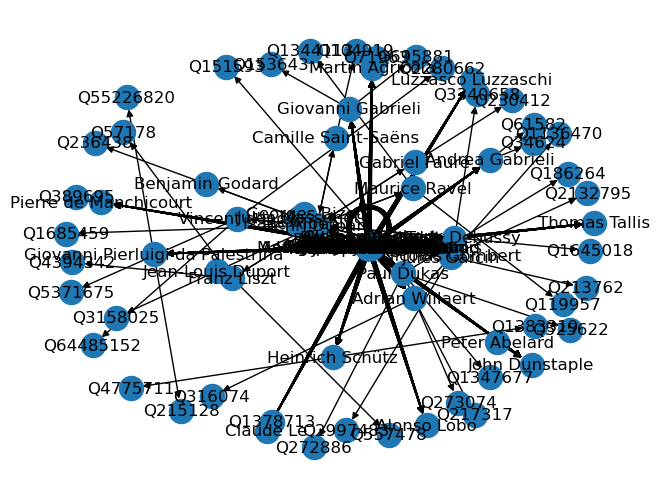

In [11]:
nx.draw(G1, with_labels=True)#, labels = nx.get_node_attributes(graph, 'nom complet'))

In [ ]:
""" problème car sigma n'accepte pas Composer comme type pour les noeuds du graphe
graph = G
#for source, target, in graph.edges:
#    graph.edges[source, target]["color_edge"] = graph.nodes[target]["color"]
layout = {}
grid_positions = {}

angle_step = 2 * math.pi / max(1,len(graph.nodes()))
radius = 1
for i,node in enumerate(graph.nodes()):
    angle = i * angle_step
    layout[node] = {
        "x": radius * math.cos(angle),
        "y": radius * math.sin(angle)
    }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = nx.pagerank(graph)

# Visualisation avec ipysigma
sigma = Sigma(
    graph=graph,
    #raw_node_color="color",
    #raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    node_border_color_from="node",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
)


# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma"""


def prepare_sigma_with_composer_ids(original_graph):
    """Relabels a graph using Composer.id as node labels and returns a Sigma widget."""
    #id_map = {node: int(node.id.replace('Q','')) for node in original_graph.nodes()}
    id_map={node: str(node)+" - "+str(node.id) for node in original_graph.nodes()}
    graph = nx.relabel_nodes(original_graph, id_map)

    # Clean all node/edge attributes to make sure they're JSON serializable
    for n, d in graph.nodes(data=True):
        for k, v in d.items():
            if not isinstance(v, (str, int, float, bool, type(None))):
                d[k] = str(v)

    for u, v, d in graph.edges(data=True):
        for k, val in d.items():
            if not isinstance(val, (str, int, float, bool, type(None))):
                d[k] = str(val)

    layout = {
        node: {
            "x": math.cos(i * 2 * math.pi / len(graph)),
            "y": math.sin(i * 2 * math.pi / len(graph)),
        }
        for i, node in enumerate(graph)
    }

    pagerank_scores = nx.pagerank(graph)

    for k, v in pagerank_scores.items():
        assert isinstance(v, (int, float)), f"Non-numeric pagerank for node {k}: {v}"

    sigma = Sigma(
        graph=graph,
        layout=layout,
        default_edge_type="curve",
        node_border_color_from="node",
        label_font="cursive",
        node_size=pagerank_scores
    )

    return sigma

#prepare_sigma_with_composer_ids(G)
import pickle
from ipysigma import Sigma

def sigma_graph_from_file(filename):
    G = pickle.load(open(filename, 'rb'))
    return G,prepare_sigma_with_composer_ids(G)
    

#S=prepare_sigma_with_composer_ids(G)
#G,S = sigma_graph_from_file("dict_keys(['Q134085', 'Q3398651', 'Q450483', 'Q347190', 'Q594586', 'Q1192', 'Q312979', 'Q7945638', 'Q2837653', 'Q49325']).pickle")
#G,S = sigma_graph_from_file("Q1387086.pickle")
#G,S = sigma_graph_from_file("Q964256.pickle")
G,S = sigma_graph_from_file("Q50187.pickle")
nx.draw(G,with_labels=True)
S


Sigma(nx.DiGraph with 1,487 nodes and 287,988 edges)

In [ ]:
G,S = sigma_graph_from_file("Q313374.pickle")
nx.draw(G,with_labels=True)
S

In [ ]:
S=prepare_sigma_with_composer_ids(G1)
S